# Проект: Прогнозирование стоимости недвижимости

**Цель проекта:** построить и протестировать несколько моделей регрессии
для прогнозирования стоимости объекта недвижимости по его характеристикам,
а также разработать приложение с формой ввода, дашбордом и справочной
информацией.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Знакомство с данными

## Загрузка данных

In [2]:
df = pd.read_csv("D:/7semestr/ML/real_estate_project/data/real_estate_data.csv", index_col=0)

C:\Users\Liliann\AppData\Local\Temp\ipykernel_14076\1017052678.py:1: DtypeWarning: Columns (9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("D:/7semestr/ML/real_estate_project/data/real_estate_data.csv", index_col=0)


In [3]:
df.shape

(403487, 16)

In [4]:
df.head()

,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
id,,,,,,,,,,,,,,,,
1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


In [5]:
df.tail()

,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
id,,,,,,,,,,,,,,,,
403483,Konut,Daire,9/18/18,NaN,2,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,NaN,1500.0,TRY
403484,Konut,Daire,10/11/18,NaN,1,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,NaN,120000.0,TRY
403485,Konut,Daire,11/22/18,NaN,1,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,NaN,48000.0,EUR
403486,Konut,Daire,2/21/19,NaN,2,6,NaN,NaN,NaN,2+1,2.0,Aydın/Kuşadası/Türkmen,NaN,NaN,900.0,TRY
403487,Konut,Daire,1/15/19,1/18/19,1,3,NaN,NaN,NaN,3+1,140.0,Kayseri/Melikgazi/Alpaslan,NaN,NaN,210000.0,TRY


In [8]:
df.sample(1, random_state=42)

,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
id,,,,,,,,,,,,,,,,
60624,Konut,Daire,11/20/18,2/23/19,1,95,6-10 arası,5,1,2+1,120.0,Antalya/Alanya/Oba,NaN,Klima,240000.0,TRY


## Описание набора данных

**Источник данных:** платформа Zingat — турецкий онлайн-сервис объявлений
о недвижимости, выступающий посредником между покупателями и продавцами.
Датасет содержит информацию об объектах недвижимости, выставленных на
продажу и в аренду.

**Целевая переменная:** `price` — стоимость объекта недвижимости.

**Признаки:**

- **type** (Тип недвижимости): категориальный признак. Значение `Konut`
  соответствует жилой недвижимости.
- **sub_type** (Подтип недвижимости): категориальный признак. Значение
  `Daire` соответствует квартире.
- **start_date** (Дата публикации): дата, когда объявление стало активным
  на рынке.
- **end_date** (Дата снятия): дата, когда объявление перестало быть
  активным.
- **listing_type** (Тип листинга): категориальный признак с двумя
  значениями — `Satılık` (продажа) и `Kiralık` (аренда).
- **tom** (Time on market): время нахождения объекта на рынке.
- **building_age** (Возраст здания): возраст постройки в годах.
  Значение `arası` означает «между» (диапазон).
- **total_floor_count** (Этажность): общее количество этажей в здании.
- **room_count** (Количество комнат): например, `2+1` означает
  2 комнаты + 1 гостиная.
- **size** (Площадь): площадь объекта в м².

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 403487 entries, 1 to 403487
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   type               403487 non-null  object 
 1   sub_type           403487 non-null  object 
 2   start_date         403487 non-null  object 
 3   end_date           266298 non-null  object 
 4   listing_type       403487 non-null  int64  
 5   tom                403487 non-null  int64  
 6   building_age       376097 non-null  object 
 7   total_floor_count  375466 non-null  object 
 8   floor_no           368191 non-null  object 
 9   room_count         403487 non-null  object 
 10  size               257481 non-null  float64
 11  address            403487 non-null  object 
 12  furnished          0 non-null       float64
 13  heating_type       375517 non-null  object 
 14  price              402772 non-null  float64
 15  price_currency     402772 non-null  object 
dtypes: floa

Датасет содержит 403 487 записей и 16 столбцов: 3 числовых (float64 — size, furnished, price), 2 целочисленных (int64 — tom, floor_no) и 11 категориальных (object). Заметны пропуски в end_date, building_age, total_floor_count, floor_no, size, heating_type, price и price_currency, а столбец furnished пуст полностью (0 non-null).

## Анализ пропущенных значений

Проверим количество пропущенных значений в каждом столбце.

Определим количество уникальных значений в каждом столбце.
Это поможет понять, какие признаки являются категориальными и насколько много в них различных категорий.


In [10]:
df.describe()

,listing_type,tom,size,furnished,price
count,403487.000000,403487.000000,257481.000000,0.0,4.027720e+05
mean,1.294235,57.022739,279.349094,NaN,3.546417e+05
std,0.467733,44.358933,9429.195331,NaN,4.809503e+06
min,1.000000,0.000000,1.000000,NaN,-2.500000e+02
25%,1.000000,29.000000,85.000000,NaN,2.500000e+03
50%,1.000000,40.000000,110.000000,NaN,1.990000e+05
75%,2.000000,90.000000,140.000000,NaN,3.420000e+05
max,3.000000,180.000000,948235.000000,NaN,2.000000e+09


Числовые признаки содержат серьёзные аномалии: отрицательные и экстремальные цены, нереалистичные площади, полностью пустой furnished и закодированный как число категориальный listing_type. Всё это требует очистки, обработки выбросов и корректного приведения типов на этапе предобработки.

In [11]:
df.nunique()

type                    1
sub_type               12
start_date            181
end_date              181
listing_type            3
tom                   181
building_age           14
total_floor_count      12
floor_no               44
room_count             37
size                  943
address              7842
furnished               0
heating_type           16
price                3703
price_currency          4
dtype: int64

In [12]:
df.isnull().sum()

type                      0
sub_type                  0
start_date                0
end_date             137189
listing_type              0
tom                       0
building_age          27390
total_floor_count     28021
floor_no              35296
room_count                0
size                 146006
address                   0
furnished            403487
heating_type          27970
price                   715
price_currency          715
dtype: int64

Так как мы выяснили что furnished полностью пуст, то удаляем его во избежании.

In [13]:
df = df.drop(columns=['furnished'])

In [14]:
# Чиним типы данных, чтобы не дублировать код
df['price'] = pd.to_numeric(df['price'], errors='coerce')

def get_total_rooms(x):
    try:
        return sum(int(part) for part in str(x).split('+'))
    except ValueError:
        return np.nan

df['room_count'] = df['room_count'].apply(get_total_rooms)

In [15]:
# Удаляем явный мусор: NaN в цене, отрицательная цена, NaN в комнатах
df = df[df['price'].notna() & (df['price'] > 0) & (df['room_count'].notna())].copy()

In [16]:
df['listing_type'].value_counts()

listing_type
1    284454
2    113829
3      2137
Name: count, dtype: int64

Третий тип слишком малочисленен и на нем невозможно будет обучить точные модели, так что удалим его 

In [17]:
df = df[df['listing_type'] != 3].copy()

In [18]:
# Чиним целевую переменную (price) и признак количества комнат (room_count)
# Приводим price к числовому типу, все "мусорные" строки станут NaN
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [19]:
# Функция для парсинга комнат
def get_total_rooms(x):
    try:
        # Если это уже число, просто возвращаем его
        if isinstance(x, (int, float)):
            return int(x)
        # Иначе разделяем по '+' и суммируем
        parts = str(x).split('+')
        return sum(int(p) for p in parts)
    except (ValueError, TypeError):
        return np.nan

In [20]:
df['room_count'] = df['room_count'].apply(get_total_rooms)

In [21]:
# Разделяем на два независимых датасета
df_sale = df[df['listing_type'] == 1].copy() 
df_rent = df[df['listing_type'] == 2].copy()

In [22]:
# Удаляем столбец listing_type, так как он больше не нужен (внутри каждого датасета он константа)
df_sale = df_sale.drop(columns=['listing_type'])
df_rent = df_rent.drop(columns=['listing_type'])

In [23]:
# Фильтруем аномалии и пропуски для выборок
# Оставляем только строки, где цена > 0, цена не NaN, и комнаты не NaN
df_sale = df_sale[df_sale['price'].notna() & (df_sale['price'] > 0) & df_sale['room_count'].notna()].copy()
df_rent = df_rent[df_rent['price'].notna() & (df_rent['price'] > 0) & df_rent['room_count'].notna()].copy()

In [24]:
print("Статистика по ценам:")
print(f"Продажа: min = {df_sale['price'].min():,.0f}, max = {df_sale['price'].max():,.0f}, mean = {df_sale['price'].mean():,.0f}".replace(",", " "))
print(f"Аренда:  min = {df_rent['price'].min():,.0f}, max = {df_rent['price'].max():,.0f}, mean = {df_rent['price'].mean():,.0f}".replace(",", " "))

Статистика по ценам:
Продажа: min = 1  max = 1 650 000 000  mean = 469 080
Аренда:  min = 3  max = 999 999 100  mean = 16 814


### Визуальный анализ

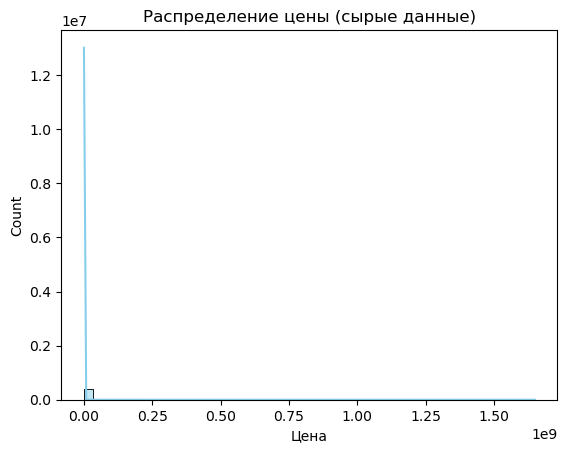

In [25]:
df_vis = df[df['price'] > 0].copy()
# Гистограмма распределения цены
plt.figure()
sns.histplot(df_vis['price'], bins=50, kde=True, color='skyblue')
plt.title('Распределение цены (сырые данные)')
plt.xlabel('Цена')
plt.show()

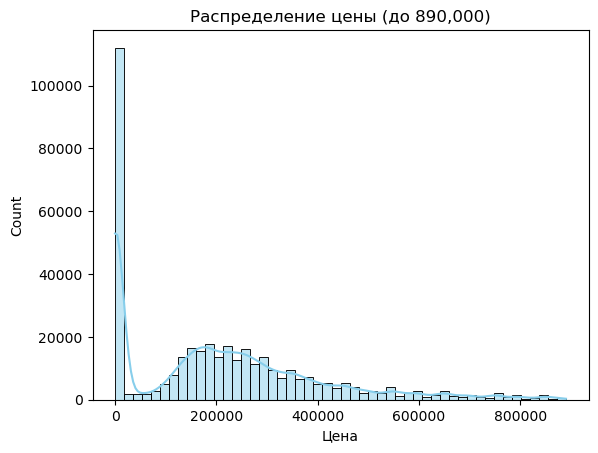

In [26]:
df_vis = df[df['price'] > 0].copy()
price_limit = df_vis['price'].quantile(0.95)  # 95% данных

plt.figure()
sns.histplot(df_vis[df_vis['price'] <= price_limit]['price'], bins=50, kde=True, color='skyblue')
plt.title(f'Распределение цены (до {price_limit:,.0f})')
plt.xlabel('Цена')
plt.show()

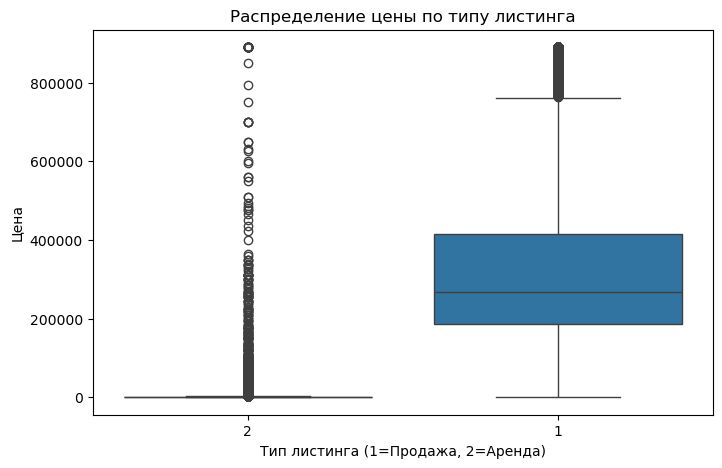

In [27]:
# Boxplot: распределение цены по типу сделки (1-продажа, 2-аренда)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_vis['listing_type'].astype(str), 
            y=df_vis['price'].clip(upper=price_limit))
plt.title('Распределение цены по типу листинга')
plt.xlabel('Тип листинга (1=Продажа, 2=Аренда)')
plt.ylabel('Цена')
plt.show()

**Продажа**: медиана ~270 000 TRY, основной разброс 190 000–420 000, много выбросов до ~900 000. Это основная масса данных.
**Аренда**: цены прижаты к нулю (аренда значительно дешевле продажи), но есть выбросы — вероятно, элитная аренда или ошибки в данных.
**Аномалия** Нужно будет удалить.
Тип листинга критически влияет на цену — стоит строить модели отдельно для продажи и аренды.


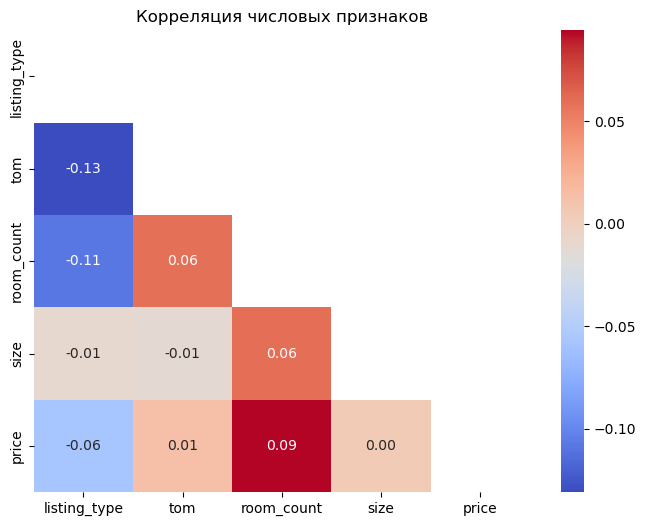

In [28]:
# Корреляционная матрица только для числовых признаков
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['number'])
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", mask=mask)
plt.title('Корреляция числовых признаков')
plt.show()

# EDA